# Exploratory Data Analysis

This notebook is where we get to know the data before touching any modeling code. We're working with the Kaggle Playground Series S6E6 stellar classification dataset, plus the original SDSS17 dataset it was synthetically generated from. The target is a 3-class label: GALAXY, QSO, or STAR.

By the end of this notebook we'll know the shape and quality of the data, how balanced the classes are, which features correlate with the target, and where the outliers sit.

In [ ]:
import pandas as pd
import os
import sys
sys.path.append(os.path.abspath('..'))

from src.utils import show_count_plots, show_corr, show_outliers
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## Loading the data

We load three files: the competition train and test sets, and the original SDSS17 dataset. We'll keep the original around for comparison and later use it to add real observations into training.

In [ ]:
raw_path = r'..\data\raw'

save_cls_dis = r'..\Data Visualizations\Class Distributions'
save_data_corr = r'..\Data Visualizations\Data Correletion'
save_data_ol = r'..\Data Visualizations\Data Outliers'

org_dataset_path = os.path.join(raw_path,"star_classification.csv")
train_path = os.path.join(raw_path,'train.csv')
test_path = os.path.join(raw_path,'test.csv')
orig_df = pd.read_csv(org_dataset_path)
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

The original dataset has extra SDSS metadata columns (run IDs, plate numbers, and so on) that the competition data doesn't have. We trim it down to the columns both datasets share.

In [ ]:
orig_df = orig_df[['alpha','delta','u','g','r','i','z','redshift','class']]

## A first look

Let's check the head and tail of each dataframe to get a feel for the columns and value ranges.

In [ ]:
orig_df.head()

,alpha,delta,u,g,r,i,z,redshift,class
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,0.634794,GALAXY
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,0.779136,GALAXY
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,0.644195,GALAXY
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,0.932346,GALAXY
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,0.116123,GALAXY


In [ ]:
orig_df.tail()

,alpha,delta,u,g,r,i,z,redshift,class
99995,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,0.000000,GALAXY
99996,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,0.404895,GALAXY
99997,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,0.143366,GALAXY
99998,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,0.455040,GALAXY
99999,196.896053,49.464643,22.62171,21.79745,20.60115,20.00959,19.28075,0.542944,GALAXY


In [ ]:
train_df.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [ ]:
train_df.tail()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
577342,577342,223.539288,2.503680,20.828729,18.854201,17.703108,17.190536,16.551356,0.511524,M,Red_Sequence,GALAXY
577343,577343,223.895970,40.769343,23.734743,22.359173,20.697865,19.180264,18.947275,0.658589,M,Red_Sequence,GALAXY
577344,577344,52.258927,0.671887,21.944250,21.215856,19.025966,18.772276,18.203397,0.376342,M,Red_Sequence,GALAXY
577345,577345,247.362248,50.659819,21.969881,21.622766,20.987575,20.930924,21.478134,2.868359,G/K,Blue_Cloud,QSO
577346,577346,194.633820,-1.307079,21.244353,21.101997,20.809379,20.866345,20.495411,1.101004,A/F,Blue_Cloud,QSO


In [ ]:
test_df.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
0,577347,120.719779,23.924249,23.668066,21.951680,21.086183,20.180032,19.202124,0.429042,G/K,Red_Sequence
1,577348,219.414419,42.171651,24.902933,22.338822,20.732163,19.860330,19.687691,0.867305,M,Red_Sequence
2,577349,173.568731,-1.756400,19.427591,18.474633,17.551314,16.570674,16.176765,0.224234,G/K,Blue_Cloud
3,577350,184.903993,-1.411074,23.121029,21.526855,20.670159,20.417633,20.699095,0.066507,G/K,Red_Sequence
4,577351,222.487816,15.381403,25.094282,22.643981,21.123173,19.439500,19.094158,0.977218,M,Red_Sequence


In [ ]:
test_df.tail()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
247430,824777,248.013903,49.533434,21.563545,21.716868,21.670791,21.265478,21.558618,1.214520,A/F,Blue_Cloud
247431,824778,226.823885,52.635936,21.434441,21.075412,20.778300,20.962333,21.010822,1.004950,A/F,Blue_Cloud
247432,824779,232.879335,44.948125,23.294670,22.336583,20.121142,19.405430,18.744581,0.269394,M,Red_Sequence
247433,824780,351.396802,2.451824,20.882944,20.902010,20.222812,20.551737,20.278339,1.199392,G/K,Blue_Cloud
247434,824781,192.793671,35.844331,22.836145,21.790448,20.620442,19.833623,19.399572,0.544832,M,Red_Sequence


The `id` column is just a row identifier, it carries no signal for the model so we drop it from both train and test.

In [ ]:
train_df.drop('id',inplace=True,axis=1)
test_df.drop('id',inplace=True,axis=1)

Quick sanity check on row and column counts across all three sets.

In [ ]:
print(f'Original Shape Is {orig_df.shape}')
print(f'Train Shape Is {train_df.shape}')
print(f'Test Shape Is {test_df.shape}')

Original Shape Is (100000, 9)
Train Shape Is (577347, 11)
Test Shape Is (247435, 10)


## Distributions

`describe()` gives us the min, max, and quartiles for every numeric column. This is where we'll spot anything that looks off, like impossible magnitude values.

In [ ]:
for col in train_df.columns[:-3]:
    print(f"{col} Describe: \n{train_df[col].describe()}")
    print("="*40)

alpha Describe: 
count    577347.000000
mean        181.616673
std          96.242941
min           0.011684
25%         132.161499
50%         188.681465
75%         231.829693
max         359.999810
Name: alpha, dtype: float64
delta Describe: 
count    577347.000000
mean         21.834654
std          18.933570
min         -17.966988
25%           2.474097
50%          21.484412
75%          36.988310
max          79.158322
Name: delta, dtype: float64
u Describe: 
count    577347.000000
mean         22.441926
std           2.018135
min          -0.139225
25%          20.977090
50%          22.570222
75%          23.869103
max          28.253263
Name: u, dtype: float64
g Describe: 
count    577347.000000
mean         21.007273
std           1.795426
min          13.535483
25%          19.865005
50%          21.467820
75%          22.292715
max          27.620208
Name: g, dtype: float64
r Describe: 
count    577347.000000
mean         19.962811
std           1.648964
min          12.57

In [ ]:
for col in orig_df.columns[:-3]:
    print(f"{col} Describe: \n{train_df[col].describe()}")
    print("="*40)

alpha Describe: 
count    577347.000000
mean        181.616673
std          96.242941
min           0.011684
25%         132.161499
50%         188.681465
75%         231.829693
max         359.999810
Name: alpha, dtype: float64
delta Describe: 
count    577347.000000
mean         21.834654
std          18.933570
min         -17.966988
25%           2.474097
50%          21.484412
75%          36.988310
max          79.158322
Name: delta, dtype: float64
u Describe: 
count    577347.000000
mean         22.441926
std           2.018135
min          -0.139225
25%          20.977090
50%          22.570222
75%          23.869103
max          28.253263
Name: u, dtype: float64
g Describe: 
count    577347.000000
mean         21.007273
std           1.795426
min          13.535483
25%          19.865005
50%          21.467820
75%          22.292715
max          27.620208
Name: g, dtype: float64
r Describe: 
count    577347.000000
mean         19.962811
std           1.648964
min          12.57

## Data types and missing values

Checking dtypes and null counts for the original dataset first.

In [ ]:
orig_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   alpha     100000 non-null  float64
 1   delta     100000 non-null  float64
 2   u         100000 non-null  float64
 3   g         100000 non-null  float64
 4   r         100000 non-null  float64
 5   i         100000 non-null  float64
 6   z         100000 non-null  float64
 7   redshift  100000 non-null  float64
 8   class     100000 non-null  str    
dtypes: float64(8), str(1)
memory usage: 7.3 MB


In [ ]:
orig_df.isna().sum()

alpha       0
delta       0
u           0
g           0
r           0
i           0
z           0
redshift    0
class       0
dtype: int64

And the class balance in the original dataset.

In [ ]:
orig_df['class'].value_counts()

class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64

In [ ]:
sorted(set(orig_df['class'].values))

['GALAXY', 'QSO', 'STAR']

Now the same checks on the competition training set.

In [ ]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   alpha              577347 non-null  float64
 1   delta              577347 non-null  float64
 2   u                  577347 non-null  float64
 3   g                  577347 non-null  float64
 4   r                  577347 non-null  float64
 5   i                  577347 non-null  float64
 6   z                  577347 non-null  float64
 7   redshift           577347 non-null  float64
 8   spectral_type      577347 non-null  str    
 9   galaxy_population  577347 non-null  str    
 10  class              577347 non-null  str    
dtypes: float64(8), str(3)
memory usage: 58.5 MB


In [ ]:
train_df.isna().sum()

alpha                0
delta                0
u                    0
g                    0
r                    0
i                    0
z                    0
redshift             0
spectral_type        0
galaxy_population    0
class                0
dtype: int64

The competition data also has `spectral_type` and `galaxy_population`, two categorical columns the original dataset doesn't have. We'll look at their distributions too.

In [ ]:
train_df['class'].value_counts()

class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64

In [ ]:
train_df['spectral_type'].value_counts()

spectral_type
M      303323
A/F    122122
G/K    108546
O/B     43356
Name: count, dtype: int64

In [ ]:
train_df['galaxy_population'].value_counts()

galaxy_population
Red_Sequence    319565
Blue_Cloud      257782
Name: count, dtype: int64

In [ ]:
sorted(set(train_df['class'].values))

['GALAXY', 'QSO', 'STAR']

## Visualizing class balance

Bar and pie charts make the imbalance easier to read than raw counts.

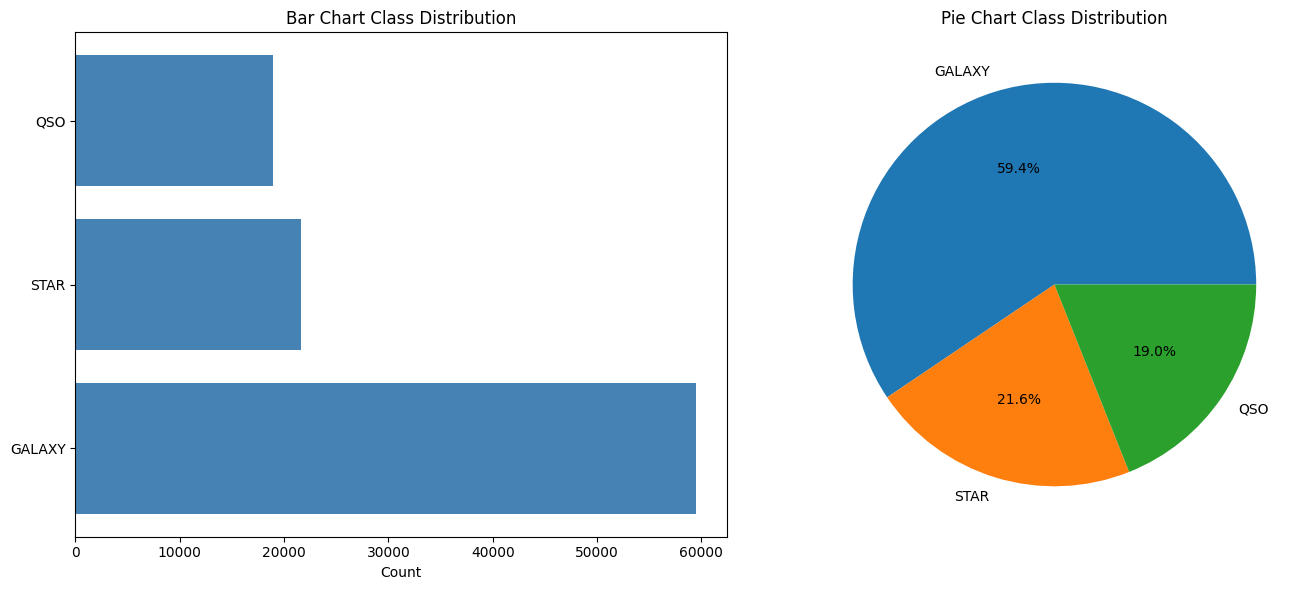

In [ ]:
show_count_plots(orig_df,'class',save_path=os.path.join(save_cls_dis,'class chart (Original Dataset).png'))

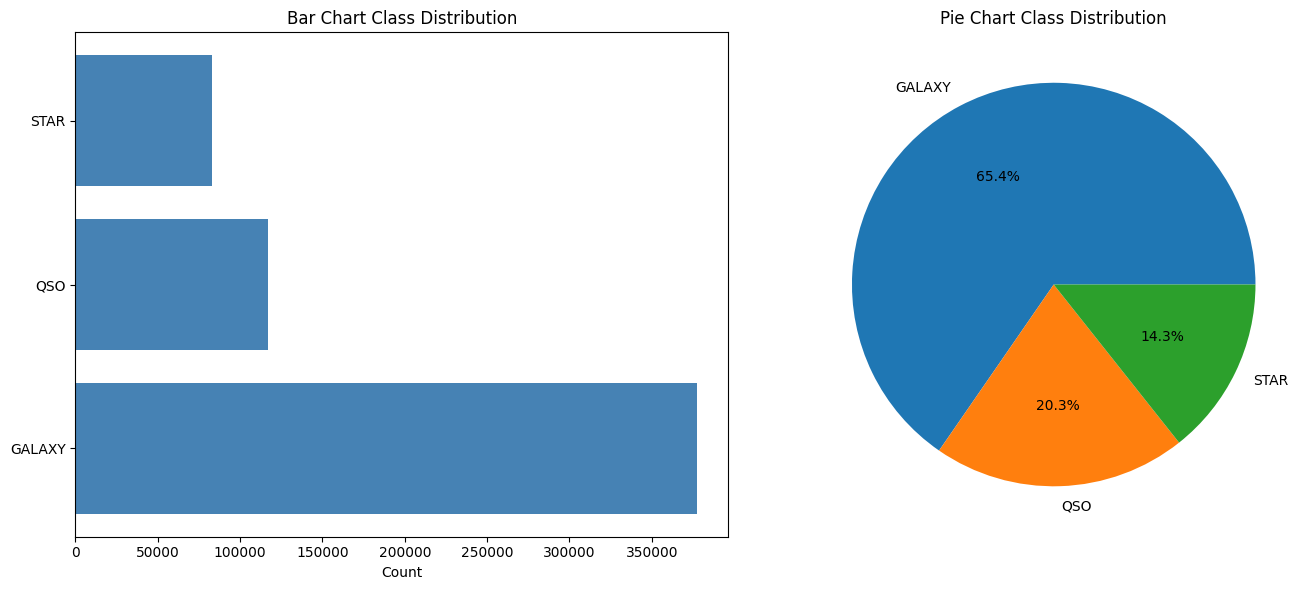

In [ ]:
show_count_plots(train_df,'class',save_path=os.path.join(save_cls_dis,'class chart.png'))

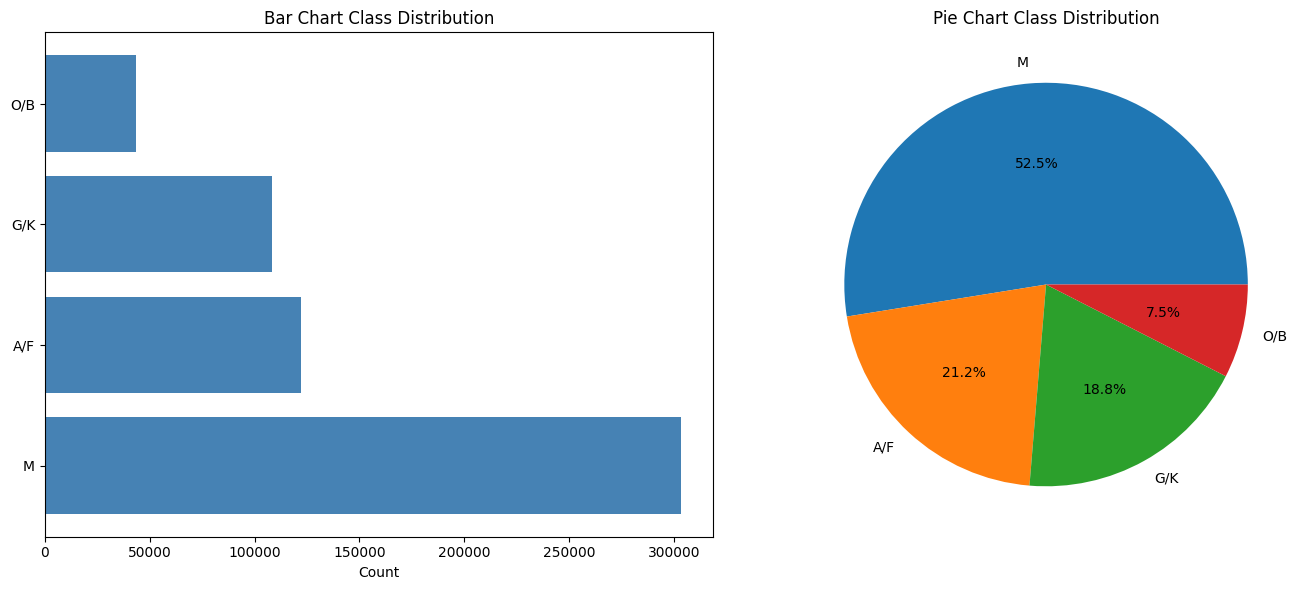

In [ ]:
show_count_plots(train_df,'spectral_type',save_path=os.path.join(save_cls_dis,'spectral_type chart.png'))

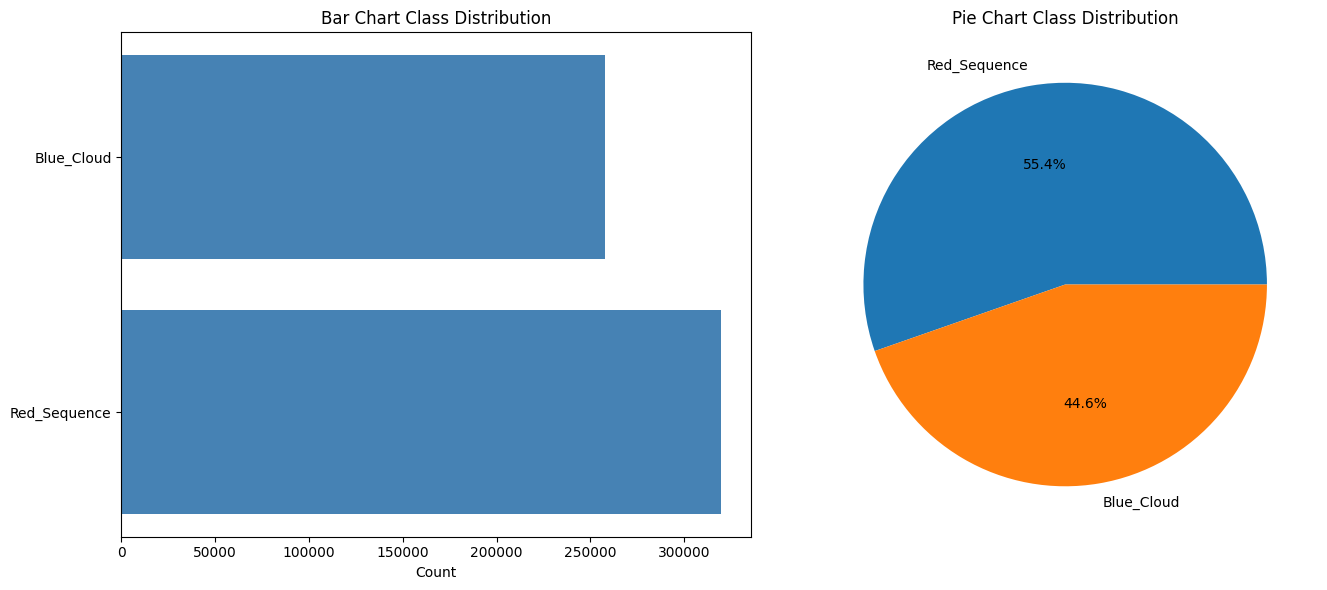

In [ ]:
show_count_plots(train_df,'galaxy_population',save_path=os.path.join(save_cls_dis,'galaxy_population chart.png'))

## Encoding the target

We label-encode the class column on both dataframes so we can run correlation and later modeling on a numeric target.

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()
orig_df['class'] = le.fit_transform(orig_df['class'])
train_df['class'] = le.fit_transform(train_df['class'])

`spectral_type` and `galaxy_population` are categorical with no real ordering, so we one-hot encode them instead of label encoding.

In [ ]:
train_df_dummies = pd.get_dummies(train_df[train_df.columns[-3:-1]],dtype=int)
train_df_dummies

,spectral_type_A/F,spectral_type_G/K,spectral_type_M,spectral_type_O/B,galaxy_population_Blue_Cloud,galaxy_population_Red_Sequence
0,0,0,1,0,0,1
1,0,0,1,0,0,1
2,0,0,0,1,1,0
3,0,0,1,0,0,1
4,0,0,1,0,0,1
...,...,...,...,...,...,...
577342,0,0,1,0,0,1
577343,0,0,1,0,0,1
577344,0,0,1,0,0,1
577345,0,1,0,0,1,0


In [ ]:
train_df.drop(train_df.columns[-3:-1],inplace=True,axis=1)

In [ ]:
train_df = pd.concat([train_df,train_df_dummies],axis=1)
train_df

,id,alpha,delta,u,g,r,i,z,redshift,class,spectral_type_A/F,spectral_type_G/K,spectral_type_M,spectral_type_O/B,galaxy_population_Blue_Cloud,galaxy_population_Red_Sequence
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,0,0,0,1,0,0,1
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,0,0,0,1,0,0,1
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,1,0,0,0,1,1,0
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,0,0,0,1,0,0,1
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577342,577342,223.539288,2.503680,20.828729,18.854201,17.703108,17.190536,16.551356,0.511524,0,0,0,1,0,0,1
577343,577343,223.895970,40.769343,23.734743,22.359173,20.697865,19.180264,18.947275,0.658589,0,0,0,1,0,0,1
577344,577344,52.258927,0.671887,21.944250,21.215856,19.025966,18.772276,18.203397,0.376342,0,0,0,1,0,0,1
577345,577345,247.362248,50.659819,21.969881,21.622766,20.987575,20.930924,21.478134,2.868359,1,0,1,0,0,1,0


## Correlation

Let's see which features actually move with the target, and check for any pairs of features that are basically duplicates of each other.

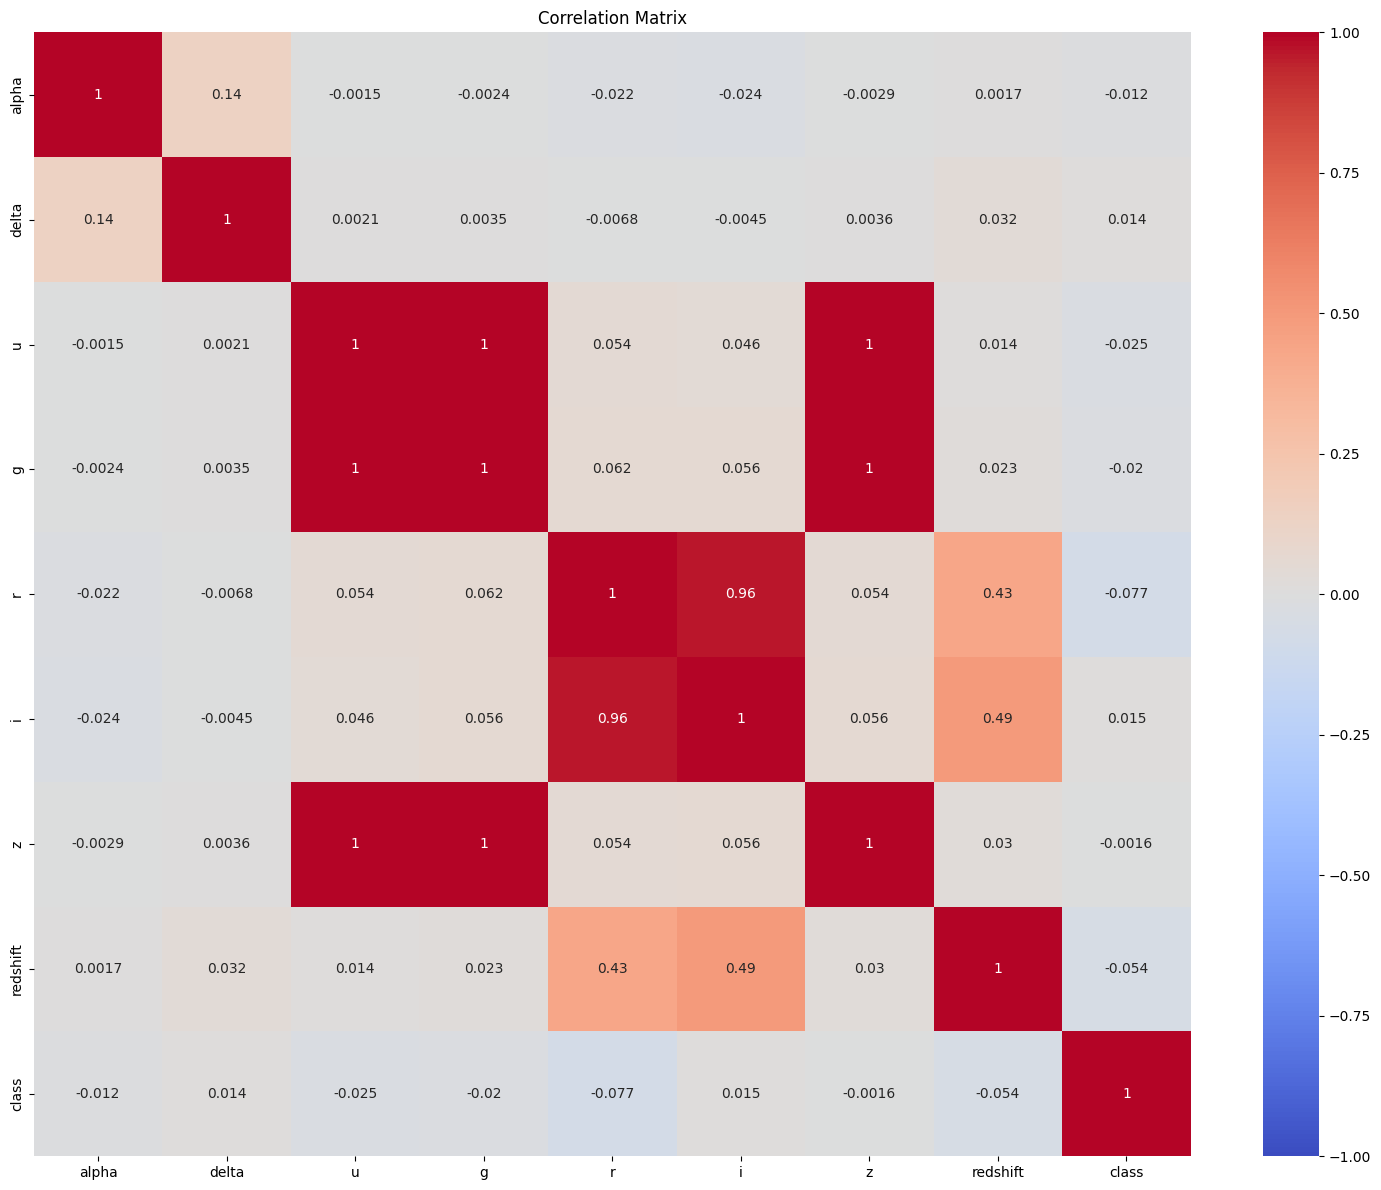

In [ ]:
show_corr(orig_df,save_path=os.path.join(save_data_corr,'full data corr (Original Dataset).png'))

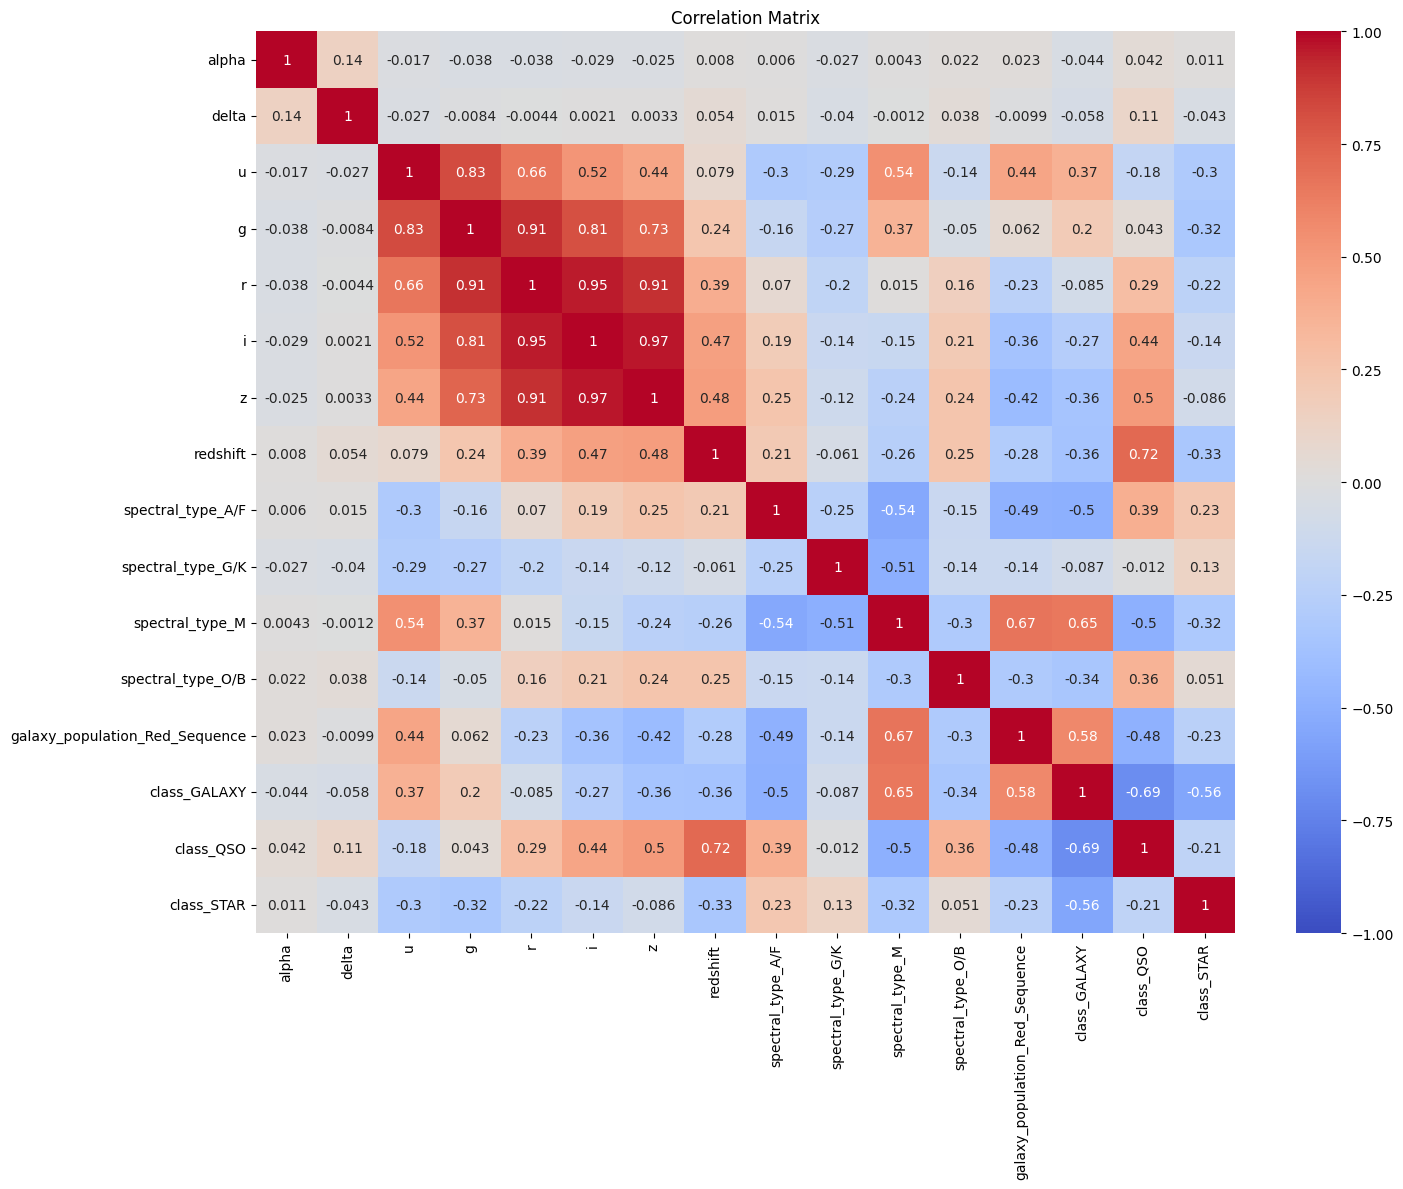

In [ ]:
show_corr(train_df,save_path=os.path.join(save_data_corr,'full data corr.png'))

## Outliers

A boxplot across all columns shows us where the spread is and which columns have extreme values worth a closer look.

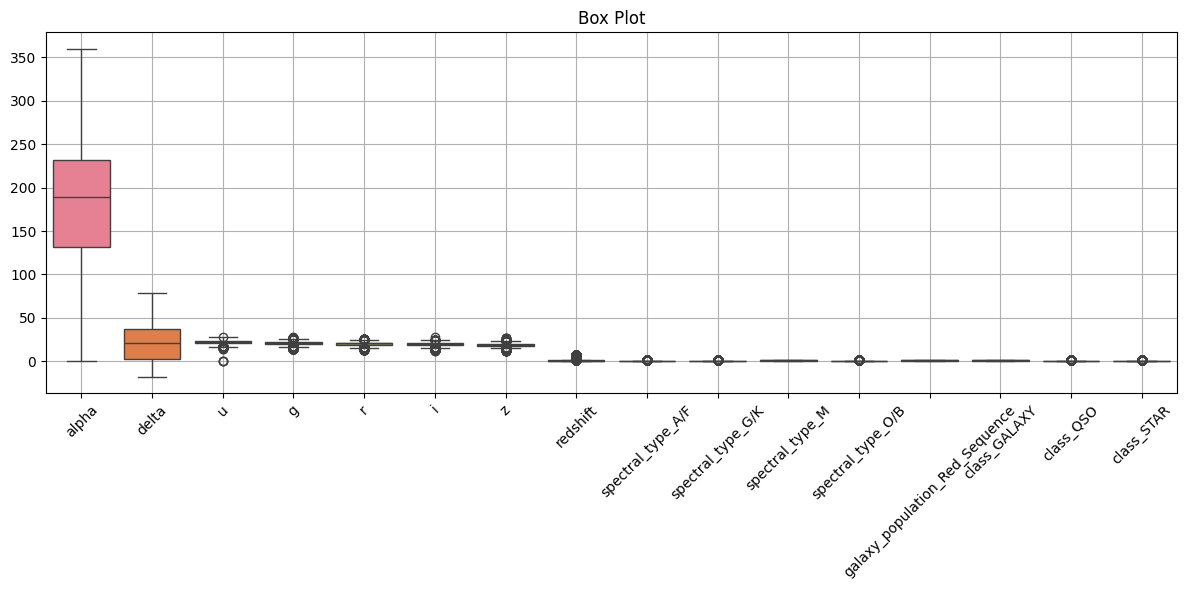

In [ ]:
show_outliers(train_df)

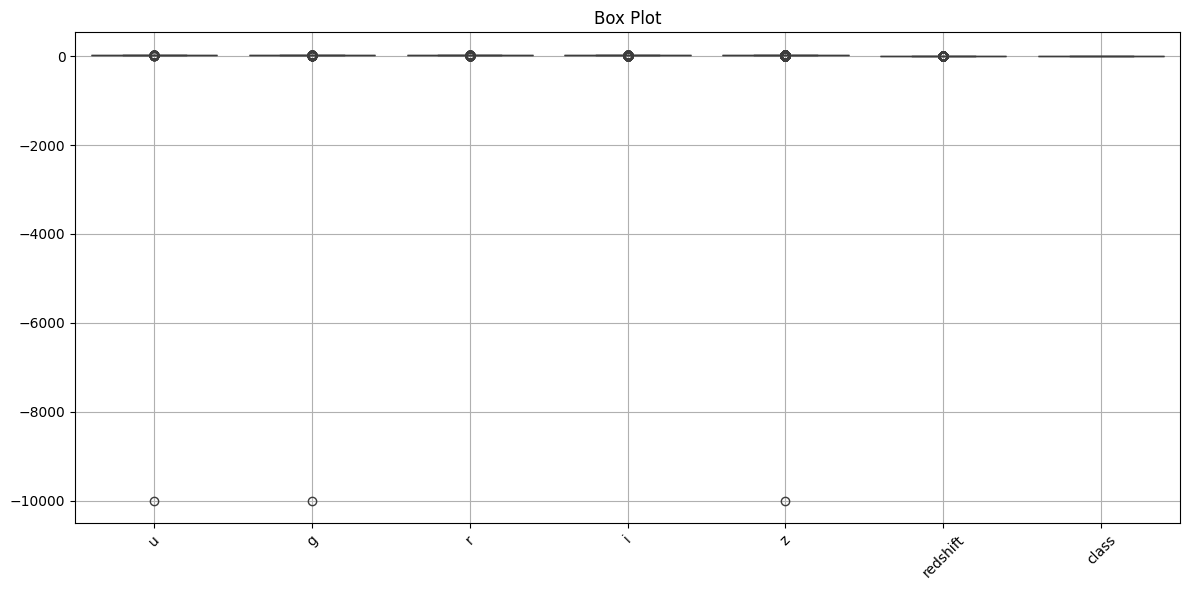

In [ ]:
show_outliers(orig_df)

The original dataset has at least one row with a magnitude of -9999, a known SDSS sentinel value for a failed reading rather than a real measurement. We find and drop it.

In [ ]:
orig_df[orig_df['u'] <= -9999]

,alpha,delta,u,g,r,i,z,redshift,class
79543,224.006526,-0.624304,-9999.0,-9999.0,18.1656,18.01675,-9999.0,0.000089,2


In [ ]:
# row 79543 has the -9999 sentinel value, drop it as a bad reading
orig_df.drop(79543,inplace=True,axis=0)

With that bad row gone, let's look at the boxplots again, skipping the id-like first columns so the scale isn't thrown off.

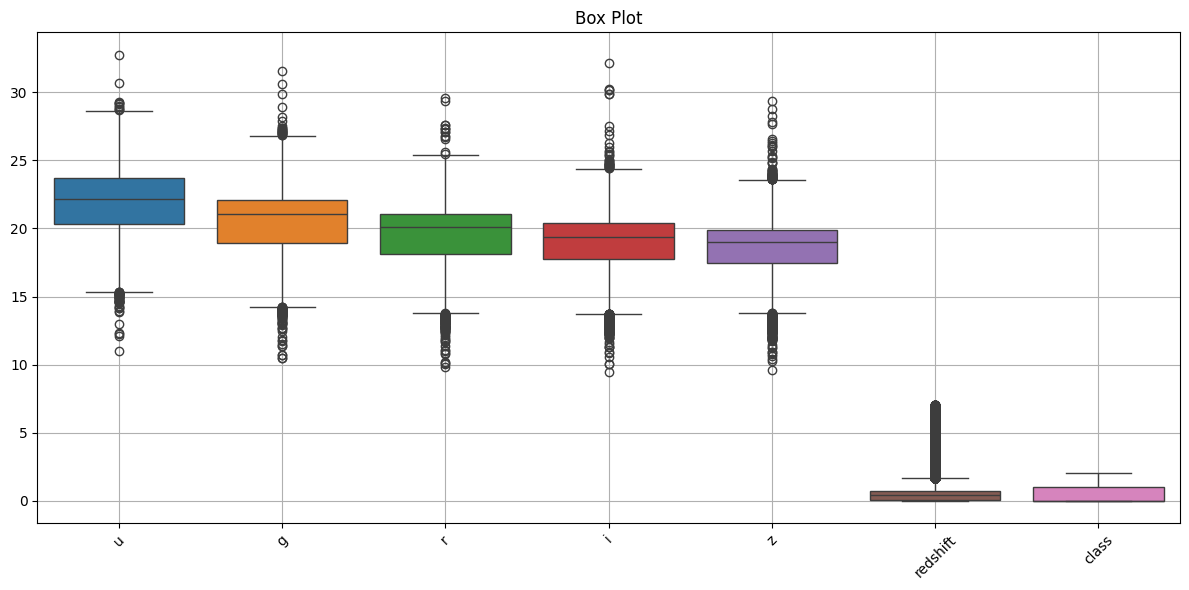

In [ ]:
show_outliers(orig_df[orig_df.columns[2:]],save_path=os.path.join(save_data_ol,'full data outliers (Original Dataset).png'))

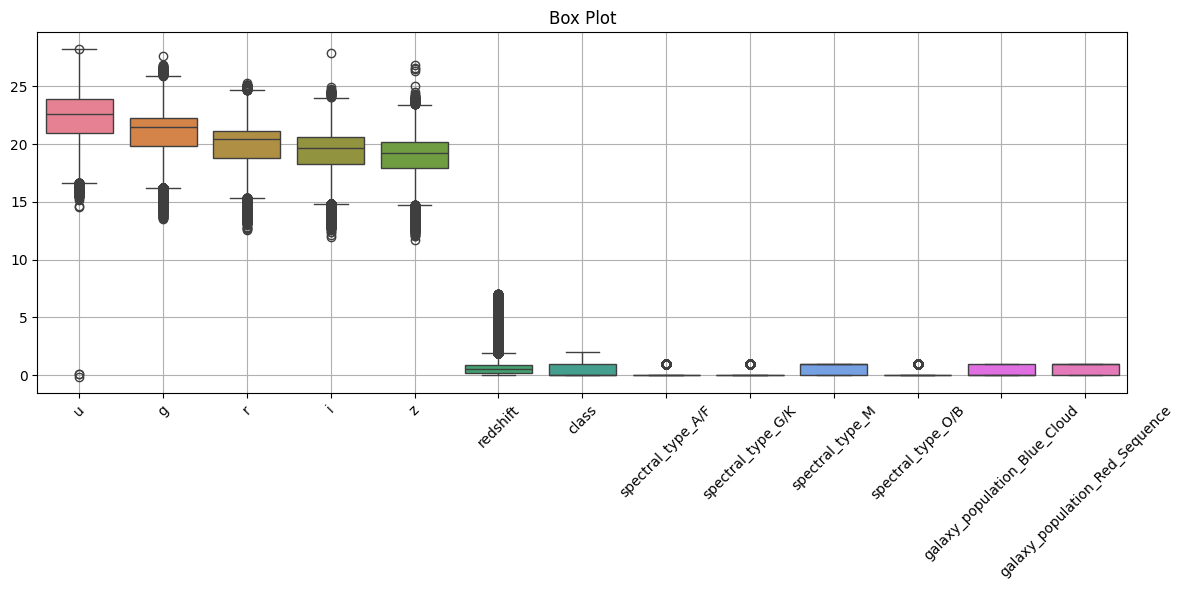

In [ ]:
show_outliers(train_df[train_df.columns[2:]],save_path=os.path.join(save_data_ol,'full data outliers.png'))